In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import load_npz

matrix = load_npz("../data/processed/interaction_matrix.npz")
interactions = pd.read_parquet("../data/processed/interactions.parquet")

with open("../data/processed/user_encoder.pkl", "rb") as f:
    user_enc = pickle.load(f)
with open("../data/processed/artist_encoder.pkl", "rb") as f:
    artist_enc = pickle.load(f)

print(f"Matrix: {matrix.shape}, nnz: {matrix.nnz:,}")

Matrix: (74999, 145778), nnz: 3,664,980


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.recommenders.matrix_factorization import SVDRecommender
import time

svd_rec = SVDRecommender(n_factors=100)

start = time.time()
svd_rec.fit(matrix, user_enc, artist_enc, interactions)
print(f"Fit time: {time.time()-start:.2f}s")

Running truncated SVD: (74999, 145778) → 100 factors...
SVD complete.
User factors:   (74999, 100)
Artist factors: (145778, 100)
Top singular values: [46.9  29.54 25.77 22.86 22.21]
Fit time: 4.66s


In [4]:
sample_user = interactions["user_id"].iloc[100]

start = time.time()
svd_recs = svd_rec.recommend(sample_user, k=10)
print(f"Query time: {time.time()-start:.4f}s")
print(svd_recs.to_string(index=False))

Query time: 0.1107s
              artist_name  svd_score recommendation_source
            jenifer lópez     0.8125                svd_mf
                  baladas     0.8125                svd_mf
                   fergie     0.7850                svd_mf
          jose el frances     0.7485                svd_mf
           beatriz luengo     0.7369                svd_mf
       julio iglesias jr.     0.7351                svd_mf
         marcos hernández     0.7351                svd_mf
                     Àëñó     0.7351                svd_mf
celine dion & bryan adams     0.7343                svd_mf
            jose galisteo     0.7305                svd_mf


In [5]:
# Item-based CF collapsed to popularity at high sparsity
# SVD artist similarity should find genuinely related artists
# because it operates in dense latent space, not sparse co-occurrence

test_artists = ["radiohead", "metallica", "black eyed peas"]

for artist in test_artists:
    print(f"\nSVD similar artists to '{artist}':")
    print(svd_rec.similar_artists(artist, k=5).to_string(index=False))


SVD similar artists to 'radiohead':
  artist_name  similarity
form and fate      0.8250
 angela valid      0.8250
       manuok      0.8250
         aedi      0.8054
       modico      0.8054

SVD similar artists to 'metallica':
                  artist_name  similarity
                     acrosome      0.8331
neophyte vs. the stunned guys      0.8331
                       スカポンタス      0.8003
                          ｔｅ’      0.7704
                         日野賢二      0.7597

SVD similar artists to 'black eyed peas':
      artist_name  similarity
           fergie      0.7392
justin timberlake      0.6925
    nelly furtado      0.6767
   wisin & yandel      0.6763
       outlandish      0.6720


In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
with open("../data/processed/cb_recommender.pkl", "rb") as f:
    cb_rec = pickle.load(f)

popularity_df = pd.read_parquet("../data/processed/artist_popularity.parquet")
from src.recommenders.popularity import PopularityRecommender
pop_rec = PopularityRecommender()
pop_rec.fit(popularity_df, interactions)

pop_recs = pop_rec.recommend(user_id=sample_user, k=10)
cb_recs  = cb_rec.recommend_for_user(sample_user, k=10)
svd_recs = svd_rec.recommend(sample_user, k=10)

print("=" * 75)
print(f"{'POPULARITY':<20} {'CONTENT-BASED':<20} {'SVD-MF':<20}")
print("=" * 75)
for i in range(10):
    pop_art = pop_recs.iloc[i]["artist_name"] if i < len(pop_recs) else "-"
    cb_art  = cb_recs.iloc[i]["artist_name"]  if i < len(cb_recs)  else "-"
    svd_art = svd_recs.iloc[i]["artist_name"] if i < len(svd_recs) else "-"
    print(f"{pop_art:<20} {cb_art:<20} {svd_art:<20}")

pop_set = set(pop_recs["artist_name"])
cb_set  = set(cb_recs["artist_name"])
svd_set = set(svd_recs["artist_name"])

print(f"\nPopularity ∩ CB:   {len(pop_set & cb_set)}/10")
print(f"Popularity ∩ SVD:  {len(pop_set & svd_set)}/10")
print(f"CB ∩ SVD:          {len(cb_set & svd_set)}/10")

PopularityRecommender fitted on 145,778 artists.
POPULARITY           CONTENT-BASED        SVD-MF              
radiohead            ponto de equilíbrio  jenifer lópez       
the beatles          laurent wolf         baladas             
coldplay             fantasy              fergie              
red hot chili peppers miranda!             jose el frances     
muse                 miranda              beatriz luengo      
metallica            mateus e cristiano   julio iglesias jr.  
pink floyd           calvin harris        marcos hernández    
the killers          seventeen            Àëñó                
nirvana              dennis               celine dion & bryan adams
linkin park          destra               jose galisteo       

Popularity ∩ CB:   0/10
Popularity ∩ SVD:  0/10
CB ∩ SVD:          0/10


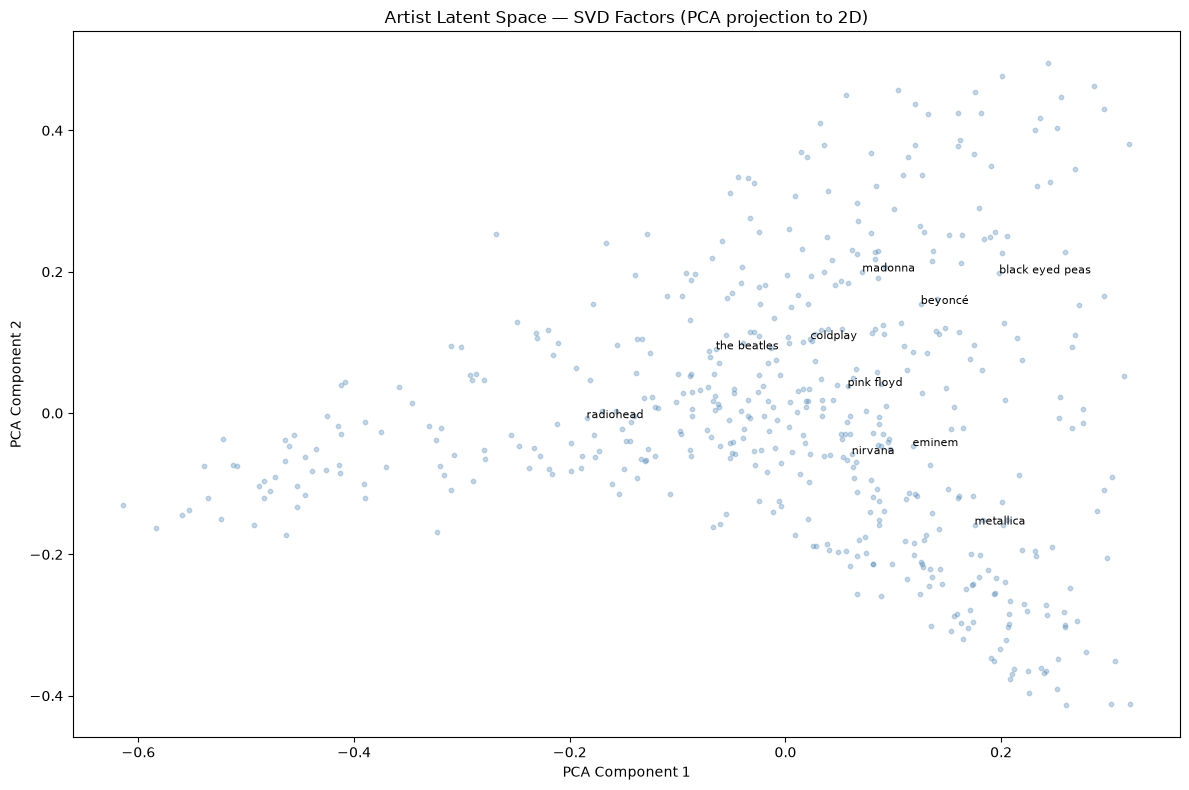

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Project 100-dim artist factors down to 2D for visualization
# Use only artists with enough listeners to be meaningful
popular_artists = popularity_df.head(500)["artist_name"].tolist()
valid_artists = [a for a in popular_artists if a in artist_enc.classes_]

indices = artist_enc.transform(valid_artists)
vectors = svd_rec.artist_factors[indices]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=10, color="steelblue")

# Label a handful of well-known artists
label_artists = [
    "radiohead", "metallica", "black eyed peas",
    "coldplay", "pink floyd", "eminem", "madonna",
    "the beatles", "nirvana", "beyoncé"
]
for artist in label_artists:
    if artist in valid_artists:
        i = valid_artists.index(artist)
        plt.annotate(artist, (coords[i, 0], coords[i, 1]), fontsize=8)

plt.title("Artist Latent Space — SVD Factors (PCA projection to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()

plt.show()

In [9]:
np.save("../data/processed/user_factors.npy", svd_rec.user_factors)
np.save("../data/processed/artist_factors.npy", svd_rec.artist_factors)

with open("../data/processed/svd_recommender.pkl", "wb") as f:
    pickle.dump(svd_rec, f)

print("SVD artifacts saved.")
print(f"User factors:   {svd_rec.user_factors.shape}")
print(f"Artist factors: {svd_rec.artist_factors.shape}")

SVD artifacts saved.
User factors:   (74999, 100)
Artist factors: (145778, 100)
